# EDA and Data Pre-processing

## 1.1 load the libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1.2 import the dataset

In [2]:
data = pd.read_csv('Admission_Predict.csv')
data.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


## 1.3 check the dimension of the data

In [3]:
data.info() # To see the data type of each of the variable, number of values entered in each of the variables

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         400 non-null    int64  
 1   GRE Score          400 non-null    int64  
 2   TOEFL Score        400 non-null    int64  
 3   University Rating  400 non-null    int64  
 4   SOP                400 non-null    float64
 5   LOR                400 non-null    float64
 6   CGPA               400 non-null    float64
 7   Research           400 non-null    int64  
 8   Chance of Admit    400 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 28.3 KB


## EDA Descriptive Statistics

## Mean

In [4]:
print("data:",data.mean()) # print the mean of each attribute. Ignore "Serial No. as it is not a continuous variable"

data: Serial No.           200.500000
GRE Score            316.807500
TOEFL Score          107.410000
University Rating      3.087500
SOP                    3.400000
LOR                    3.452500
CGPA                   8.598925
Research               0.547500
Chance of Admit        0.724350
dtype: float64


## Mode

In [5]:
print(data['GRE Score'].mode())  # Prints the mode of the attribute. There are two values with the same frequency

0    312
1    324
Name: GRE Score, dtype: int64


## Median

In [6]:
print("data:",data.median())# Print the median values of the data.

# Observe that the values of mean and median are almost the same for most of the attributes

data: Serial No.           200.50
GRE Score            317.00
TOEFL Score          107.00
University Rating      3.00
SOP                    3.50
LOR                    3.50
CGPA                   8.61
Research               1.00
Chance of Admit        0.73
dtype: float64


## Quantile 25%

In [7]:
print("Data_quantile(25%):",data.quantile(q=0.25))  # Prints the value below which 25% of the data lies

Data_quantile(25%): Serial No.           100.75
GRE Score            308.00
TOEFL Score          103.00
University Rating      2.00
SOP                    2.50
LOR                    3.00
CGPA                   8.17
Research               0.00
Chance of Admit        0.64
Name: 0.25, dtype: float64


## Quantile 50%

In [8]:
print("Data_quantile(50%):",data.quantile(q=0.50))

Data_quantile(50%): Serial No.           200.50
GRE Score            317.00
TOEFL Score          107.00
University Rating      3.00
SOP                    3.50
LOR                    3.50
CGPA                   8.61
Research               1.00
Chance of Admit        0.73
Name: 0.5, dtype: float64


## Quantile 75%

In [9]:
print("Data_quantile(75%):",data.quantile(q=0.75))

Data_quantile(75%): Serial No.           300.2500
GRE Score            325.0000
TOEFL Score          112.0000
University Rating      4.0000
SOP                    4.0000
LOR                    4.0000
CGPA                   9.0625
Research               1.0000
Chance of Admit        0.8300
Name: 0.75, dtype: float64


## 1.5a) Plotting the summery mean,mode,median using histogram

Mean:  316.8075 
Median:  317.0 
Mode:  312


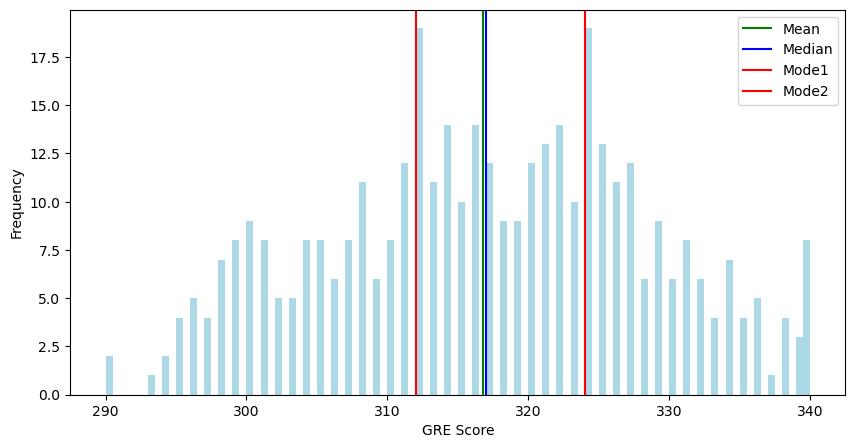

In [10]:
mean=data['GRE Score'].mean()
median=data['GRE Score'].median()
mode=data['GRE Score'].mode()

print('Mean: ',mean,'\nMedian: ',median,'\nMode: ',mode[0])

plt.figure(figsize=(10,5)) # set the figure size
plt.hist(data['GRE Score'],bins=100,color='lightblue') #Plot the histogram

plt.axvline(mean,color='green',label='Mean')     # Draw lines on the plot for mean median and the two modes we have in GRE Score
plt.axvline(median,color='blue',label='Median')
plt.axvline(mode[0],color='red',label='Mode1')
plt.axvline(mode[1],color='red',label='Mode2')

plt.xlabel('GRE Score')   # label the x-axis
plt.ylabel('Frequency')   # label the y-axis
plt.legend()              # Plot the legend
plt.show()

## 1.6 Check the data.describe()

In [11]:
data.describe() # the output results provide the five number summary of the data.

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,200.500000,316.807500,107.410000,3.087500,3.400000,3.452500,8.598925,0.547500,0.724350
std,115.614301,11.473646,6.069514,1.143728,1.006869,0.898478,0.596317,0.498362,0.142609
min,1.000000,290.000000,92.000000,1.000000,1.000000,1.000000,6.800000,0.000000,0.340000
25%,100.750000,308.000000,103.000000,2.000000,2.500000,3.000000,8.170000,0.000000,0.640000
50%,200.500000,317.000000,107.000000,3.000000,3.500000,3.500000,8.610000,1.000000,0.730000
75%,300.250000,325.000000,112.000000,4.000000,4.000000,4.000000,9.062500,1.000000,0.830000
max,400.000000,340.000000,120.000000,5.000000,5.000000,5.000000,9.920000,1.000000,0.970000


## IQR Value for TOEFL Score

In [12]:
data["TOEFL Score"].quantile(0.75) - data["TOEFL Score"].quantile(0.25)

np.float64(9.0)

## 1.6a)Undestanding the summary of Statistics plotting Box plots

Text(0.7, 107.5, 'IQR')

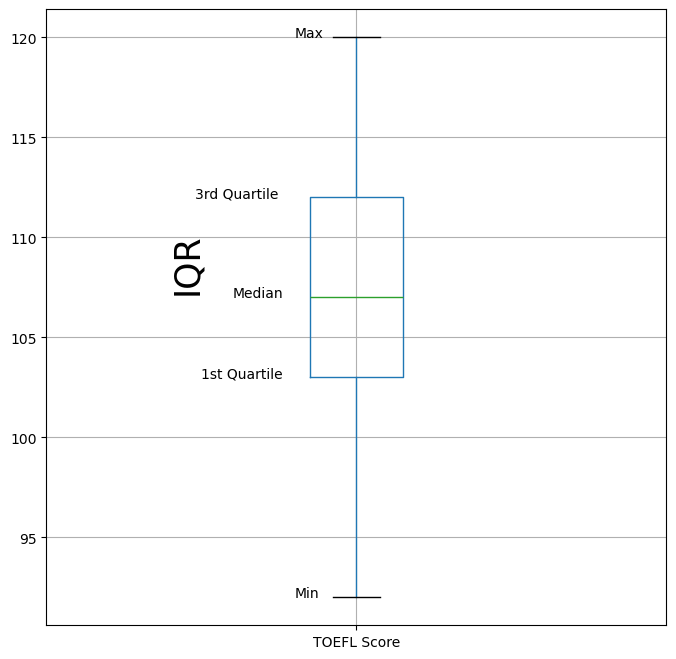

In [13]:
# Create boxplot for column="TOEFL Score"
data.boxplot(column="TOEFL Score",return_type='axes',figsize=(8,8))

# create text(x=0.74, y=22.25, s="3rd Quartile")like Median, 1st Quartile,Min,Max,IQR:
plt.text(x=0.74, y=112.00, s="3rd Quartile")
plt.text(x=0.8, y=107.00, s="Median")
plt.text(x=0.75, y=103.00, s="1st Quartile")
plt.text(x=0.9, y=92.00, s="Min")
plt.text(x=0.9, y=120.00, s="Max")
plt.text(x=0.7, y=107.5, s="IQR", rotation=90, size=25)

## 1.7 Check the Measures of Dispersion:

## IQR

In [16]:
data.quantile(0.75) - data.quantile(0.25)

Serial No.           199.5000
GRE Score             17.0000
TOEFL Score            9.0000
University Rating      2.0000
SOP                    1.5000
LOR                    1.0000
CGPA                   0.8925
Research               1.0000
Chance of Admit        0.1900
dtype: float64

## Range

In [17]:
print(data.max() - data.min())

Serial No.           399.00
GRE Score             50.00
TOEFL Score           28.00
University Rating      4.00
SOP                    4.00
LOR                    4.00
CGPA                   3.12
Research               1.00
Chance of Admit        0.63
dtype: float64


## Variance

In [18]:
print(data.var())

Serial No.           13366.666667
GRE Score              131.644555
TOEFL Score             36.838997
University Rating        1.308114
SOP                      1.013784
LOR                      0.807262
CGPA                     0.355594
Research                 0.248365
Chance of Admit          0.020337
dtype: float64


## Standard Deviation

In [19]:
print(data.std())

Serial No.           115.614301
GRE Score             11.473646
TOEFL Score            6.069514
University Rating      1.143728
SOP                    1.006869
LOR                    0.898478
CGPA                   0.596317
Research               0.498362
Chance of Admit        0.142609
dtype: float64


## 1.8 Check Covariance and Correlation

## Covariance

In [21]:
data.cov()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
Serial No.,13366.666667,-129.369674,-103.807018,-22.472431,-19.432331,-9.164160,-3.144373,-3.637845,0.698020
GRE Score,-129.369674,131.644555,58.216967,8.778791,7.079699,5.747726,5.699742,3.318690,1.313271
TOEFL Score,-103.807018,58.216967,36.838997,4.828697,4.021053,3.095965,2.998337,1.481729,0.685179
University Rating,-22.472431,8.778791,4.828697,1.308114,0.845865,0.678352,0.509117,0.255232,0.116009
SOP,-19.432331,7.079699,4.021053,0.845865,1.013784,0.660025,0.431183,0.222807,0.097028
LOR,-9.164160,5.747726,3.095965,0.678352,0.660025,0.807262,0.359084,0.177701,0.085834
CGPA,-3.144373,5.699742,2.998337,0.509117,0.431183,0.359084,0.355594,0.155026,0.074265
Research,-3.637845,3.318690,1.481729,0.255232,0.222807,0.177701,0.155026,0.248365,0.039317
Chance of Admit,0.698020,1.313271,0.685179,0.116009,0.097028,0.085834,0.074265,0.039317,0.020337


## Cor-relation

In [22]:
data.corr()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
Serial No.,1.000000,-0.097526,-0.147932,-0.169948,-0.166932,-0.088221,-0.045608,-0.063138,0.042336
GRE Score,-0.097526,1.000000,0.835977,0.668976,0.612831,0.557555,0.833060,0.580391,0.802610
TOEFL Score,-0.147932,0.835977,1.000000,0.695590,0.657981,0.567721,0.828417,0.489858,0.791594
University Rating,-0.169948,0.668976,0.695590,1.000000,0.734523,0.660123,0.746479,0.447783,0.711250
SOP,-0.166932,0.612831,0.657981,0.734523,1.000000,0.729593,0.718144,0.444029,0.675732
LOR,-0.088221,0.557555,0.567721,0.660123,0.729593,1.000000,0.670211,0.396859,0.669889
CGPA,-0.045608,0.833060,0.828417,0.746479,0.718144,0.670211,1.000000,0.521654,0.873289
Research,-0.063138,0.580391,0.489858,0.447783,0.444029,0.396859,0.521654,1.000000,0.553202
Chance of Admit,0.042336,0.802610,0.791594,0.711250,0.675732,0.669889,0.873289,0.553202,1.000000


## 1.8a) Pairplot for checking the correlation?

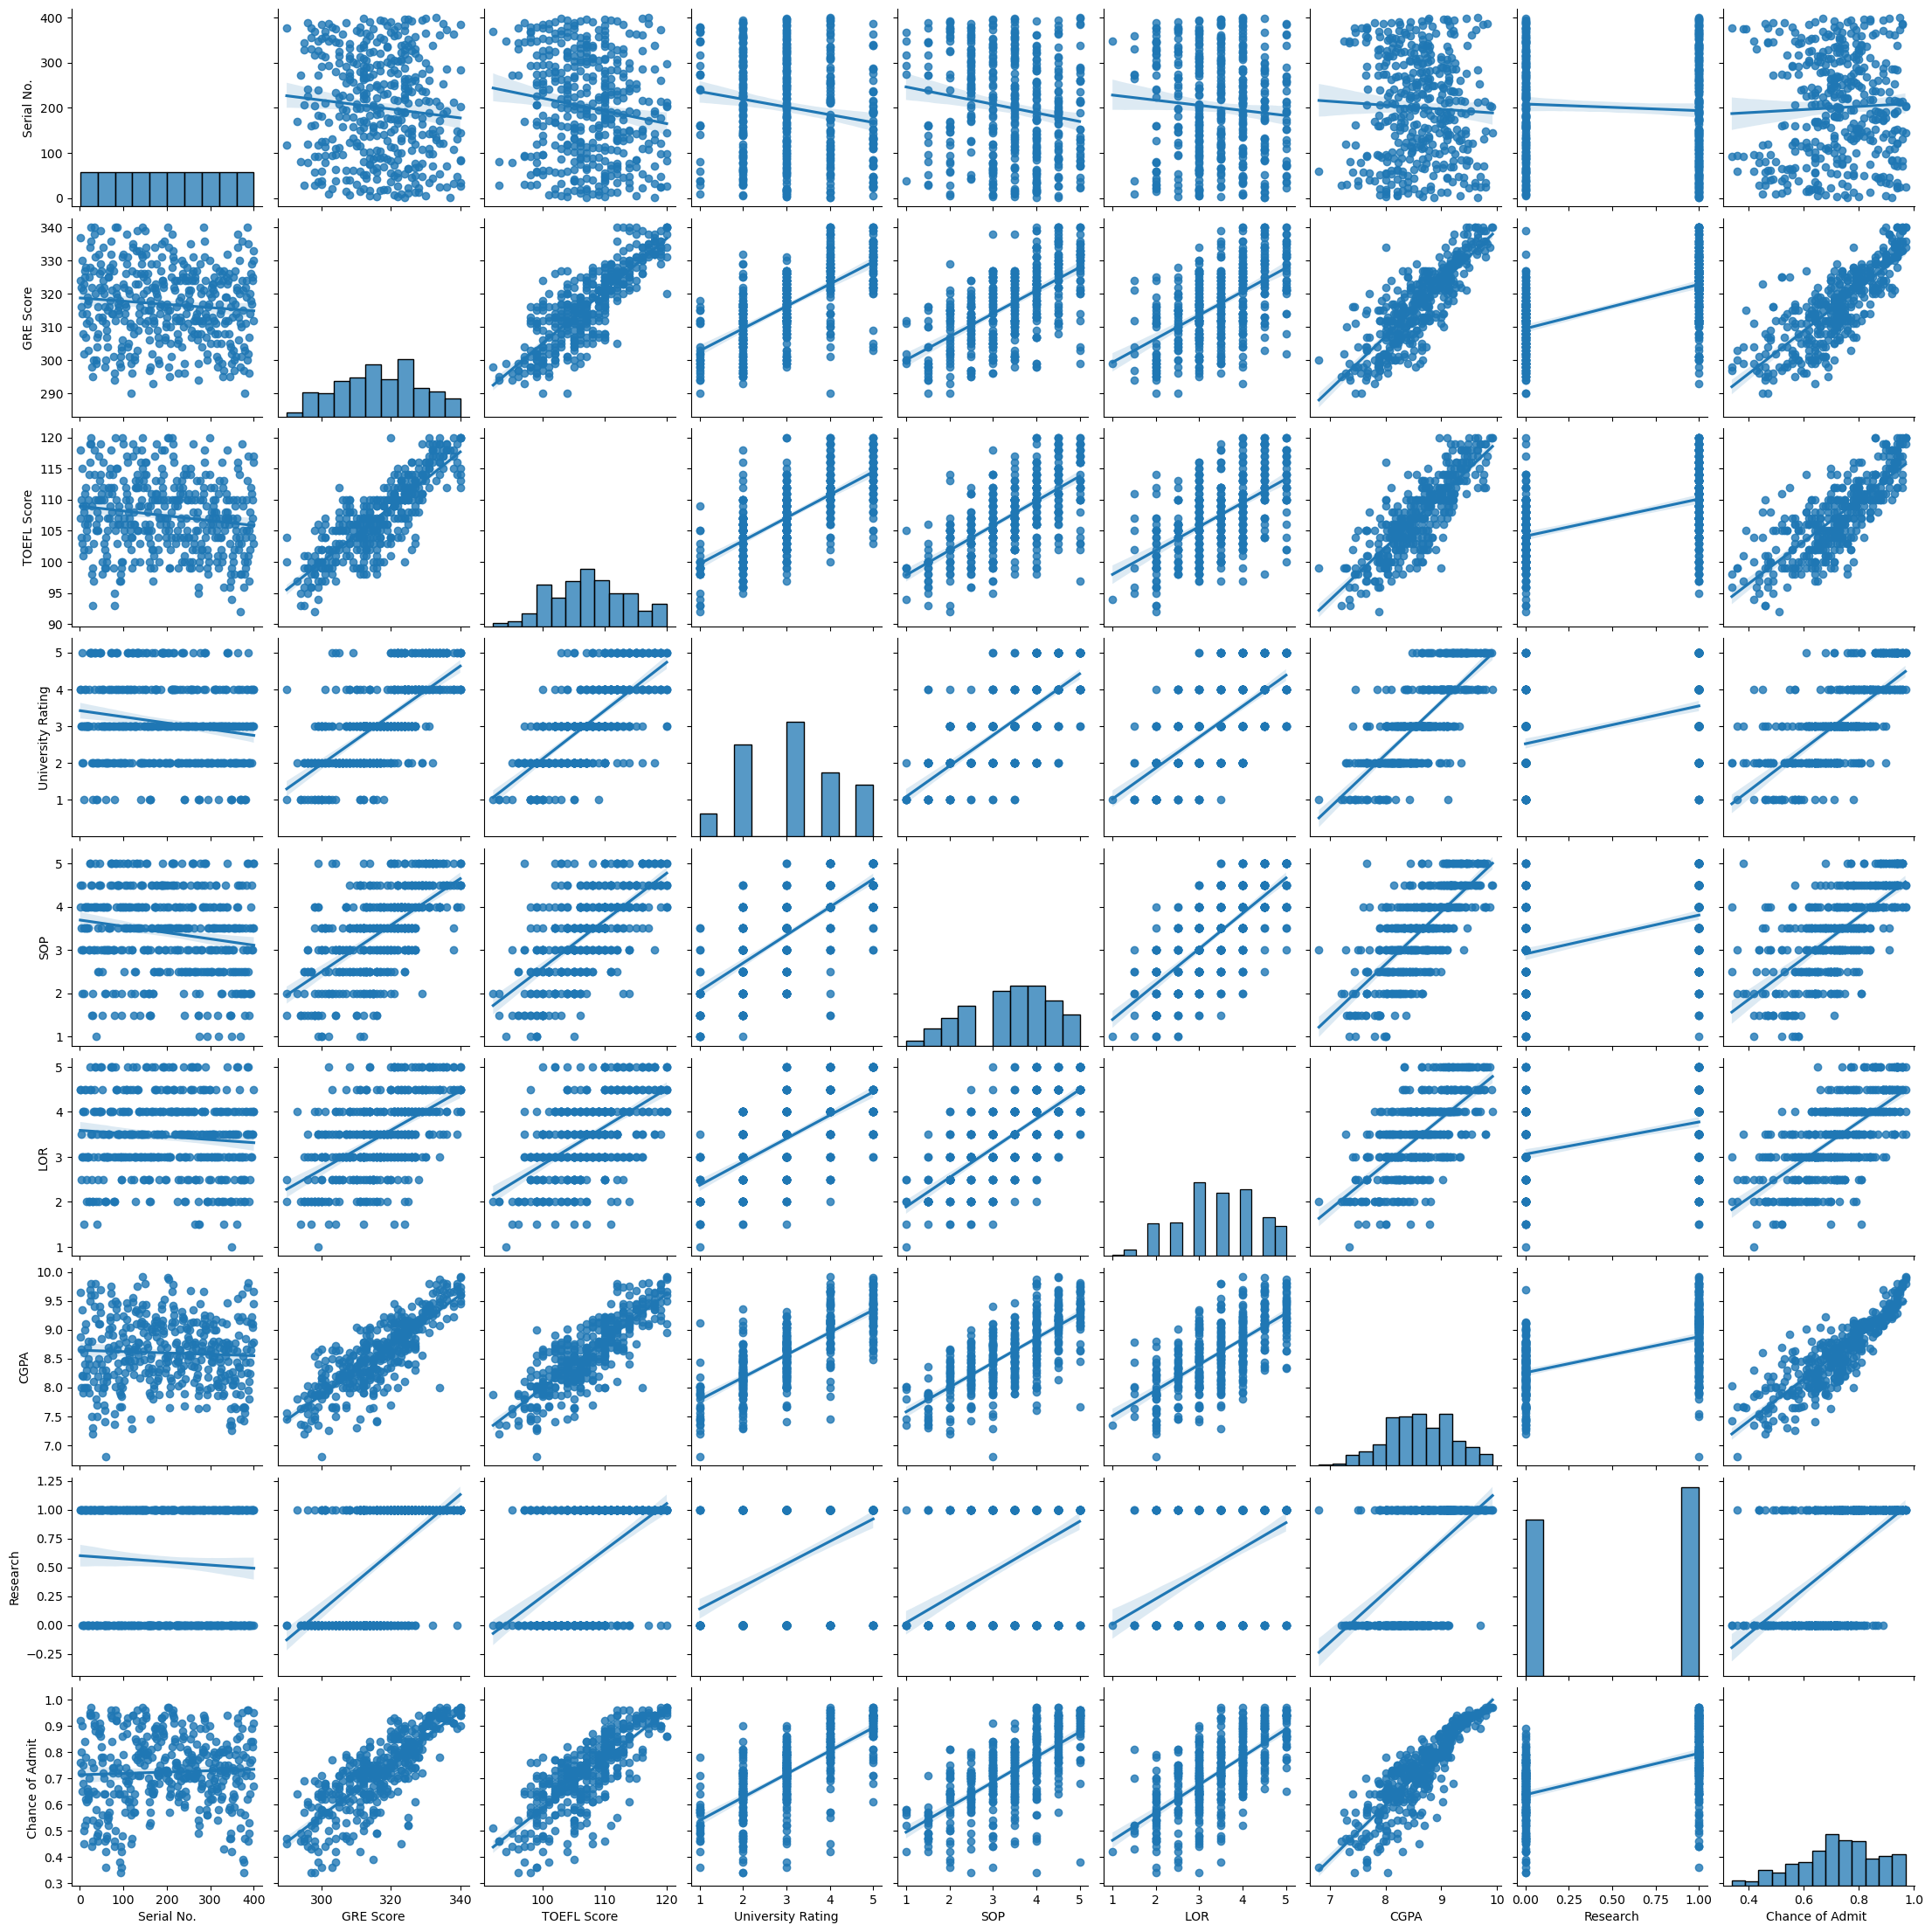

In [24]:
import seaborn as sns

sns.pairplot(data, kind="reg")  # plots scatter plots for every pair of attributes and histograms along the diagonal
plt.show()

In [25]:
data.drop('Serial No.', axis=1, inplace=True)  # to drop a column from the original dataframe

## 1.8b) Heatmap For checking the correlation?

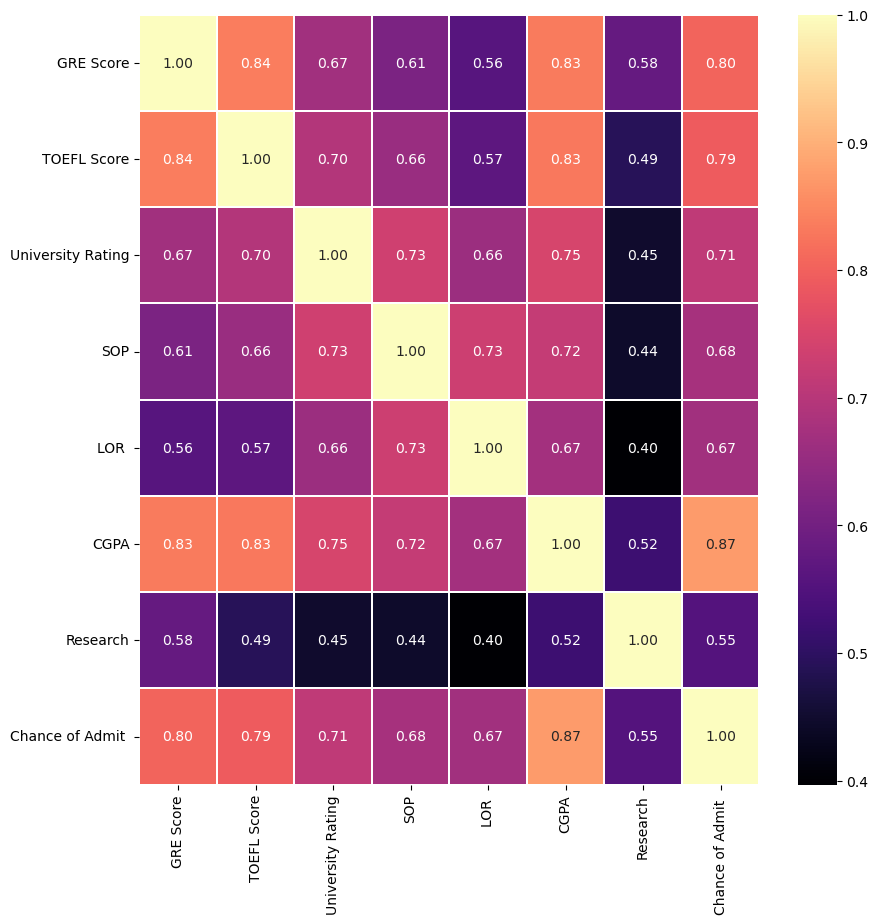

In [26]:
fig,ax = plt.subplots(figsize=(10, 10))   
sns.heatmap(data.corr(), ax=ax, annot=True, linewidths=0.05, fmt= '.2f',cmap="magma") # the color intensity is based on 
plt.show()

## 1.9 Check the Skewness and Kurtosis

Positively skewed: Most frequent values are low and tail is towards high values.

Negatively skewed: Most frequent values are high and tail is towards low values.

If Mode< Median< Mean then the distribution is positively skewed.

If Mode> Median> Mean then the distribution is negatively skewed.



In [27]:
data.skew()

GRE Score           -0.062893
TOEFL Score          0.057216
University Rating    0.171260
SOP                 -0.275761
LOR                 -0.106991
CGPA                -0.065991
Research            -0.191582
Chance of Admit     -0.353448
dtype: float64

## 1.10 Histogram for checking the Skewness

AttributeError: Rectangle.set() got an unexpected keyword argument 'normed'

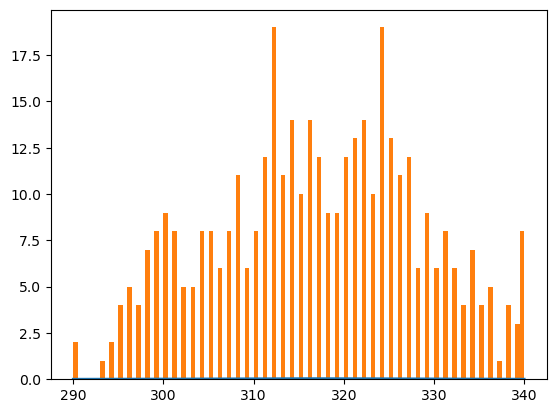

In [28]:
import scipy.stats as stats

#convert pandas DataFrame object to numpy array and sort
h = np.asarray(data['GRE Score'])
h = sorted(h)
 
#use the scipy stats module to fit a normal distirbution with same mean and standard deviation
fit = stats.norm.pdf(h, np.mean(h), np.std(h)) 
 
#plot both series on the histogram
plt.plot(h,fit,'-',linewidth = 2,label="Normal distribution with same mean and var")
plt.hist(h,normed=True,bins = 100,label="Actual distribution")      
plt.legend()
plt.show()